# Flash Drought Detection

In this notebook, we will apply the technique we learned in the previous part to a new case study in South Africa in 2024 and determine its predictive skill as an early warning of drought. In particular, we will apply a "detection rule" to the time series of SIF-RCI and SWDI to see when our data would indicate a developing flash drought. The "detection rule" is based on two primary values:

* The **drought severity**: a threshold value below which we declare a drought
* The **speed of drought development**: the length of time that an indicator changes from normal/mild to severe anomaly is a distinguishing factor for flash drought

In research, these values are chosen based on maximizing the predictive skill of the rules compared to an established catalog of flash drought \[[3](https://doi.org/10.1073/pnas.2202767119)\]\[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]\[[14](https://doi.org/10.1016/j.jhydrol.2014.12.051)\]\[[17](https://doi.org/10.5194/hess-25-565-2021)\]. For our purposes, the values can be changed subjectively, but the approach should still be informed by similar work. 

### The 2023/2024 Summer Flash Drought in South Africa

The case study for this notebook is a flash drought that occurred in South Africa during the 2023-2024 growing season (remember, December to March is summer in the Southern Hemisphere) and is discussed in detail in Malherbe et al., 2025 \[[15](https://doi.org/10.1016/j.envdev.2025.101253)\]. Although this analysis will focus on South Africa and a small portion of Lesotho, the flash drought affected a larger area across much of Southern Africa including as far north as Angola and Zambia.

In the first three cells below, we will repeat the process that was covered in the first notebook:
* Retrieve the necessary GOSIF data. As with the Great Plains case study, climatology for this region has already been processed and is located in the `inputs` directory.
* Compute time series of SIF-RCI and SWDI, saving the results as CSV. A key difference here from the previous notebook is that we will also save a geotiff of each time step of SIF-RCI and SWDI to preserve the spatial variations in these indicators for later.
* Plot the time series in a single figure.

In [1]:
"""Inputs
In this case study, we will use a portion of Free State in South Africa as a region of interest, but this notebook
is set up to make it easier for you to input your own region of interest and date range. Along with modifying the input values
in this cell, you will want to run the Appendix notebook with updated values.

Directions for using your own region:
1. Using GIS software or Google Maps, determine the coordinates of a region of interest. Currently, only rectangular regions are supported.
2. Go to the Appendix notebook (3_appendix.ipynb), run the first code cell, then follow the instructions in the second code cell.
3. Find the crop calendar for the primary crop(s) in your region of interest. This will require your own research or prior knowledge, but it is
  very important to determine if a flash drought signal is agriculturally impactful.
4. Set the following variables in this cell:
  a. region_name, plot_region_name (str): Any name you want. region_name will be used in the filenames, plot_region_name will be used in the plot title.
  b. west, south, east, north (four floats): The coordinates of the region of interest.
  c. date_range (list[datetime]): The start and end dates of the time period you want to analyze.
  d. planting_start, planting_end, harvest_start, harvest_end (four datetimes): The crop calendar dates for the region.
  e. plot_title (str): Title to be used in the plot in the fourth cell.
"""
from datetime import datetime, timedelta

# Free State South Africa region of interest
region_name = "south_africa"
plot_region_name = "Free State South Africa"
# 28.00°-29.00°S, 27.00°-28.50°E
west, south, east, north = 27.0, -29.0, 28.5, -28.0

# For the South Africa case study, we will download data from September 2023 (just before the spring planting) through to
# August 2024 (after the harvest)
date_range = [datetime(2023, 9, 1), datetime(2024, 8, 31)] # noqa: DTZ001
start, end = date_range

# Typical crop calendar for Maize (Corn) in Free State South Africa:
#   Planting: October 15 - November 15
#   Harvest:  April 1 - May 15
planting_start, planting_end = datetime(start.year, 10, 15), datetime(start.year, 11, 15) # noqa: DTZ001
harvest_start, harvest_end = datetime(end.year, 4, 1), datetime(end.year, 5, 15) # noqa: DTZ001

years = sorted({str(dt.year) for dt in date_range})
year_str = '_'.join(years)
plot_year_str = '-'.join(years)

def format_coords(coord_left: float, coord_right: float, is_lat: bool = True) -> str:
    if is_lat:
        hem_left  = "N" if coord_left > 0.0 else "S"
        hem_right = "N" if coord_right > 0.0 else "S"
    else:
        hem_left  = "E" if coord_left > 0.0 else "W"
        hem_right = "E" if coord_right > 0.0 else "W"
    hem_left = "" if hem_right == hem_left else hem_left
    return f"{abs(coord_left)}°{hem_left}-{abs(coord_right)}°{hem_right}"

plot_title = f"SIF-RCI over {plot_region_name} ({plot_year_str})\n{format_coords(north, south)}, {format_coords(west, east, is_lat=False)}"
plot2_title = f"SIF-RCI with Flash Drought Detections over {plot_region_name} ({plot_year_str})\n{format_coords(north, south)}, {format_coords(west, east, is_lat=False)}"
plot3_title = f"SWDI with Flash Drought Detections over {plot_region_name} ({plot_year_str})\n{format_coords(north, south)}, {format_coords(west, east, is_lat=False)}"

def doy_to_date(year, doy):
    return datetime(year, 1, 1) + timedelta(days=doy - 1) # noqa: DTZ001

doy_range: list[tuple[int, int]] = []
for year in range(start.year, end.year + 1):
    for doy in range(1, 365, 8):
        d = doy_to_date(year, doy)
        if start <= d <= end:
            doy_range.append((year, doy))

# Set the filename to use for the time series
sif_time_series_fname = f"{region_name}_{year_str}_sif.csv"
swdi_time_series_fname = f"{region_name}_{year_str}_swdi.csv"

# Set the directory to save the rasters for each time step
raster_dir = f"data/{region_name}_time_steps_{year_str}"
fd_dir = f"data/{region_name}_fd_{year_str}"

In [2]:
import os

from download import download_unpack_gosif
from tqdm.notebook import tqdm

output_dir = "data/gosif"
os.makedirs(output_dir, exist_ok=True)

gosif_geotiffs: list[str] = []
for year, doy in tqdm(doy_range, desc="Downloading granules"):
    fname = download_unpack_gosif(
        year,
        day=doy,
        output_dir=output_dir,
        verbose=False
    )
    if fname:
        gosif_geotiffs.append(fname)

In [3]:
from analysis import compute_sif_time_series, compute_swdi_timeseries

# Get the climatology inputs produced by the appendix notebook
clim_dir = f"inputs/sif_increments_{region_name}/"
# clim_dir = "inputs/sif_increments/"

if not os.path.exists(f"data/{sif_time_series_fname}"):
    sif_csv_path, n_dates = compute_sif_time_series(
        gosif_geotiffs,
        clim_dir,
        sif_time_series_fname,
        west, south, east, north,
        raster_dir=raster_dir,
    )
    print(f"SIF: Computed time series values for {n_dates} granules and saved to {sif_csv_path}")
else:
    sif_csv_path = f"data/{sif_time_series_fname}"

if not os.path.exists(f"data/{swdi_time_series_fname}"):
    swdi_csv_path = compute_swdi_timeseries(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d"),
        swdi_time_series_fname,
        (west, south, east, north),
        raster_dir=raster_dir,
    )
    print(f"SWDI: Saved time series values to {swdi_csv_path}")
else:
    swdi_csv_path = f"data/{swdi_time_series_fname}"

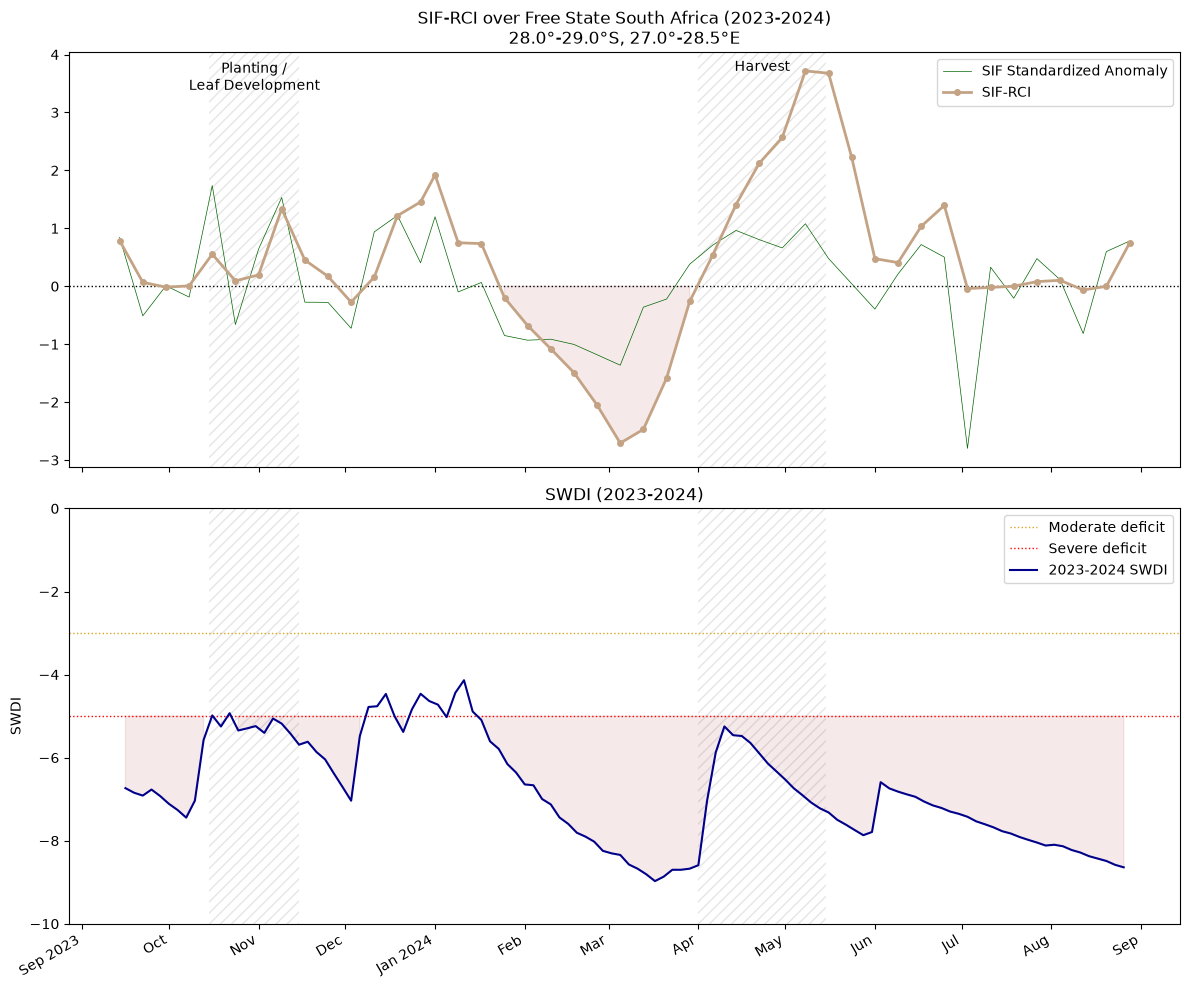

In [4]:
import csv
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms


class MonthYearFormatter(mdates.DateFormatter):
    """Overengineered x axis tick label formatter."""

    def format_ticks(self, values):
        dates = [mdates.num2date(v) for v in values]
        labels = []
        last_year = None
        for d in dates:
            if d.year != last_year:
                labels.append(d.strftime("%b %Y"))
                last_year = d.year
            else:
                labels.append(d.strftime("%b"))
        return labels

# Read the saved CSV
plot_dates = []
plot_zscore: list[float] = []
plot_sifrci: list[float] = []
with open(sif_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        plot_zscore.append(float(row["zscore"]))
        plot_sifrci.append(float(row["sif_rci"]))

plot2_dates = []
plot2_swdi: list[float] = []
with open(swdi_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["time"], "%Y-%m-%d") # noqa: DTZ007
        # Our time series of SWDI is slightly longer, so skip dates that aren't
        # in the SIF time series
        if pt_date < plot_dates[0] or pt_date > plot_dates[-1]:
            continue
        plot2_dates.append(pt_date)
        plot2_swdi.append(float(row["swdi"]))


# As before, we will highlight the period where the SIF-RCI signal
# was persistently below 0
flash_drought = [r < -0.05 for r in plot_sifrci]

# Like in the SWDI plot from the first notebook, we will highlight the period
# where the SWDI signal was persistently below -5
moderate_fd_thresh = -3
fd_thresh = -5
flash_drought_swdi = [r < fd_thresh for r in plot2_swdi]

def add_crop_calendar(ax: plt.Axes, label: bool = True) -> None:
    """Cross-hatch the usual planting and harvest windows and label them on the plot."""
    ax.axvspan(planting_start, planting_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    ax.axvspan(harvest_start, harvest_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    if label:
        # x in data coordinates, y in axes-fraction coordinates
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(planting_start + (planting_end - planting_start) / 2, 0.98, # type: ignore
                "Planting /\nLeaf Development", transform=trans, ha="center",
                va="top", fontsize=10, color="black")
        ax.text(harvest_start + (harvest_end - harvest_start) / 2, 0.98, # type: ignore
                "Harvest", transform=trans, ha="center", va="top",
                fontsize=10, color="black")


# Plot the time series as two stacked subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Shade the crop calendar behind both subplots (labelled on the top subplot only)
add_crop_calendar(ax1)
add_crop_calendar(ax2, label=False)

# First subplot: SIF Standardized Anomaly (z-score) and SIF-RCI
ax1.axhline(0, color="black", linestyle=":", linewidth=1)
ax1.plot(plot_dates, plot_zscore, color="darkgreen", linewidth=0.5, label="SIF Standardized Anomaly")
ax1.plot(plot_dates, plot_sifrci, marker="o", color=(0.77, 0.64, 0.52), linewidth=2, markersize=4, label="SIF-RCI")
ax1.fill_between(plot_dates, plot_sifrci, 0, where=flash_drought, color="brown", alpha=0.1)
ax1.set_title(plot_title)
ax1.legend()

# Second subplot: SWDI with threshold levels
ax2.set_ylim(-10, 0)
ax2.axhline(moderate_fd_thresh, color="goldenrod", linestyle=":", linewidth=1, label="Moderate deficit")
ax2.axhline(fd_thresh, color="red", linestyle=":", linewidth=1, label="Severe deficit")
ax2.plot(plot2_dates, plot2_swdi, color="darkblue", linewidth=1.5, label=f"{plot_year_str} SWDI")
ax2.fill_between(plot2_dates, plot2_swdi, fd_thresh, where=flash_drought_swdi, color="brown", alpha=0.1)
ax2.set_ylabel("SWDI")
ax2.set_title(f"SWDI ({plot_year_str})")
ax2.legend()

ax2.xaxis.set_major_formatter(MonthYearFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Applying Detection Rules

Now let's finally apply our rules based on the research papers we've looked at so far. Since we saved the rasters for each time step, we can apply the rule per grid cell:

### SIF-RCI
* At least 24 consecutive days (3 time steps) SIF-RCI is < -0.5

### SWDI
**Start Date**
1. SWDI decreases by at least 2 points over the preceeding 30 days (10 time steps)
2. **Moderate FD**: SWDI < -3 for at least 12 days (4 time steps) in addition to rule 1.
3. **Severe FD**: SWDI < -5 for at least 12 days in addition to rule 1.

Alternative formulation similar to SWVI:
1. SWDI for a 3-day time step is less than 21-day moving average for 4 or more time steps
2. **Moderate FD**: SWDI for a 3-day time step is less than -3
3. **Severe FD**: SWDI for a 3-day time step is less than -5
4. **Long-term drought**: 60-day moving average SWDI < -5

**End date**
1. SWDI increases by at least 2 points over the last 12 days (4 time steps)
2. SWDI > -5 for 12 days or more


### Combination

* **High confidence flash drought**: both indicators flag a start date within 16 days of each other
* **Moderate confidence flash drought**: SWDI flags a start date without a corresponding SIF-RCI start date
* **Significant SIF anomaly**: If SIF-RCI flags a start date without a corresponding SWDI start date. May not be due to FD, for example floods and fires can also cause detections.
* **Slow drought transition**: No SWDI end date detected within the time range.

Optionally, we can flag FD events that occur within the growing season, which can be defined as the start of planting season to the end of the harvest season. It would be ideal to use real data to inform these dates, but this information is typically secret for large agricultural operations and difficult to obtain from smallholder farmers. Farmers don't tend to plant and harvest their crops uniformly in lock step, so the crop calendar dates are rough estimates.  

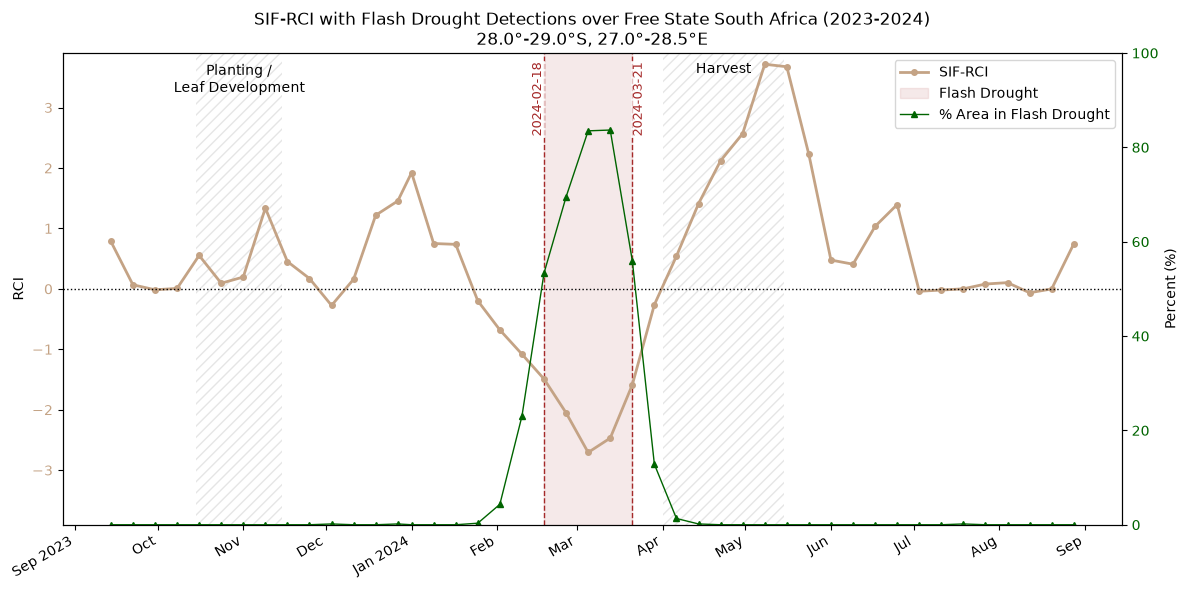

In [9]:
from analysis import detect_flash_drought_sif, detect_flash_drought_swdi

detect_flash_drought_sif(raster_dir, fd_dir, sif_csv_path)
detect_flash_drought_swdi(raster_dir, fd_dir, swdi_csv_path)

def add_flash_drought_markers(ax: plt.Axes, dates: list[datetime], flags: list[bool]) -> None:
    """Draw vertical dashed lines at the first and last dates below the flash drought threshold."""
    fd_dates = [d for d, flag in zip(dates, flags) if flag]
    if not fd_dates:
        return

    first_date, last_date = fd_dates[0], fd_dates[-1]
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    for i, d in enumerate([first_date, last_date]):
        if d == dates[-1]:
            continue
        ax.axvline(d, color="brown", linestyle="--", linewidth=1, zorder=1)
        # Alternate label alignment so start/end labels don't overlap when close together
        ha = "right" if i == 0 else "left"
        ax.text(d, 0.98, d.strftime("%Y-%m-%d"), transform=trans, ha=ha, va="top",
                fontsize=9, color="brown", rotation=90,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1})
    ax.axvspan(first_date, last_date, color="brown", alpha=0.1, label="Flash Drought")


# Read the saved CSV
plot_dates = []
plot_fdperc: list[float] = []
plot_sifrci: list[float] = []
with open(sif_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        plot_fdperc.append(float(row["fd_percent"]))
        plot_sifrci.append(float(row["sif_rci"]))

fd_thresh = 50
flash_drought_sif = [r > fd_thresh for r in plot_fdperc]

color1 = (0.77, 0.64, 0.52)
color2 = "darkgreen"

fig, ax1 = plt.subplots(figsize=(12, 6))
add_crop_calendar(ax1)
ax1.plot(plot_dates, plot_sifrci, marker="o", color=color1, linewidth=2, markersize=4, label="SIF-RCI")
ax1.axhline(0, color="black", linestyle=":", linewidth=1)
ax1.tick_params(axis='y', labelcolor=color1)
ylim = max([abs(r) for r in plot_sifrci])
ax1.set_ylim(-1.05 * ylim, 1.05 * ylim)
ax1.set_ylabel("RCI")
ax1.set_title(plot2_title)
add_flash_drought_markers(ax1, plot_dates, flash_drought_sif)


ax2 = ax1.twinx()
ax2.plot(plot_dates, plot_fdperc, marker="^", color=color2, linewidth=1, markersize=4, label="% Area in Flash Drought")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Percent (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.xaxis.set_major_formatter(MonthYearFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


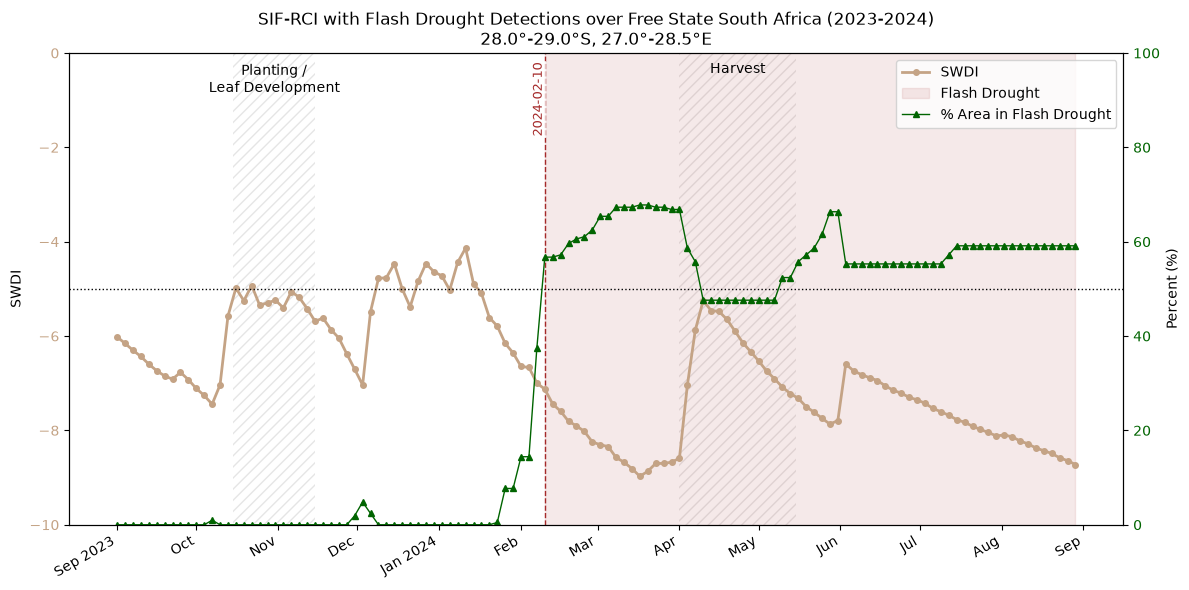

In [ ]:
# Read the saved CSV
plot_dates = []
plot_fdperc: list[float] = []
plot_swdi: list[float] = []
with open(swdi_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["time"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        plot_fdperc.append(float(row["fd_percent"]))
        plot_swdi.append(float(row["swdi"]))

fd_thresh = 50
flash_drought_swdi = [r2 > fd_thresh for r2 in plot_fdperc]

color1 = "darkblue"
color2 = "darkgreen"

fig, ax1 = plt.subplots(figsize=(12, 6))
add_crop_calendar(ax1)
ax1.plot(plot_dates, plot_swdi, marker="o", color=color1, linewidth=2, markersize=4, label="SWDI")
ax1.axhline(-5, color="black", linestyle=":", linewidth=1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(-10, 0)
ax1.set_ylabel("SWDI")
ax1.set_title(plot2_title)

add_flash_drought_markers(ax1, plot_dates, flash_drought_swdi)


ax2 = ax1.twinx()
ax2.plot(plot_dates, plot_fdperc, marker="^", color=color2, linewidth=1, markersize=4, label="% Area in Flash Drought")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Percent (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.xaxis.set_major_formatter(MonthYearFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
